# deCODE

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import io
import itertools
import os
import subprocess
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib as mpl
import msprime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scipy.optimize
import scipy.stats
import seaborn as sns
import statsmodels.stats.proportion
import tqdm
from pyliftover import LiftOver
from scipy.stats import beta

pd.set_option("display.max_rows", 1000)
plt.rcParams["pdf.use14corefonts"] = True
pl.Config.set_tbl_rows(100)
pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [3]:
repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
elif not (repo / "notebooks").exists():
    repo = Path("/nfs/users/nfs_r/rs42/rs42/git/recombination")

sys.path.insert(0, str(repo))
from src.IDs import aut_chrom_names, CO_color, NCO_color, background_color

figure_dir = repo / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

grch37_chromosome_sizes_in_bp = {
    "chr1": 249250621,
    "chr2": 243199373,
    "chr3": 198022430,
    "chr4": 191154276,
    "chr5": 180915260,
    "chr6": 171115067,
    "chr7": 159138663,
    "chr8": 146364022,
    "chr9": 141213431,
    "chr10": 135534747,
    "chr11": 135006516,
    "chr12": 133851895,
    "chr13": 115169878,
    "chr14": 107349540,
    "chr15": 102531392,
    "chr16": 90354753,
    "chr17": 81195210,
    "chr18": 78077248,
    "chr19": 59128983,
    "chr20": 63025520,
    "chr21": 48129895,
    "chr22": 51304566,
}

genetic_map_dir = Path("/lustre/scratch122/tol/projects/sperm/data/references/04.genetic_maps/01.Bherer_etal_SexualDimorphismRecombination/Refined_EUR_genetic_map_b37")

rate_maps = {}
for chrom in aut_chrom_names:
    rate_maps[chrom] = msprime.RateMap.read_hapmap(
        open(genetic_map_dir / f"male_{chrom}.txt"),
        sequence_length=grch37_chromosome_sizes_in_bp[chrom],
    )

male_rate_maps = rate_maps

female_rate_maps = {}
for chrom in aut_chrom_names:
    female_rate_maps[chrom] = msprime.RateMap.read_hapmap(
        open(genetic_map_dir / f"female_{chrom}.txt"),
        sequence_length=grch37_chromosome_sizes_in_bp[chrom],
    )

avg_rate_maps = {}
for chrom in aut_chrom_names:
    avg_rate_maps[chrom] = msprime.RateMap.read_hapmap(
        open(genetic_map_dir / f"sexavg_{chrom}.txt"),
        sequence_length=grch37_chromosome_sizes_in_bp[chrom],
    )

class maps:
    pass

annotate = maps()
annotate.rate_maps = rate_maps
annotate.male_rate_maps = male_rate_maps
annotate.female_rate_maps = female_rate_maps
annotate.avg_rate_maps = avg_rate_maps

## NCOs

In [4]:
nco_path = "/lustre/scratch122/tol/projects/sperm/data/decode/DecodeGenetics-PalssonEtAl_Nature_2024-8e49794/data/oNCOs/oNCOs.tsv"
markers_path = "/lustre/scratch122/tol/projects/sperm/data/decode/DecodeGenetics-PalssonEtAl_Nature_2024-8e49794/data/oNCOs/oNCO.markers.tsv"

In [5]:
nco_df = pl.read_csv(nco_path, separator="\t", comment_prefix="#")
markers_df = pl.read_csv(markers_path, separator="\t", comment_prefix="#")

In [6]:
male_single_nco_df = (
    nco_df
    .filter(pl.col("gcMPPs") == 1)
    .filter(pl.col("ptype") == "P")
)

female_single_nco_df = (
    nco_df
    .filter(pl.col("gcMPPs") == 1)
    .filter(pl.col("ptype") == "M")
)

In [7]:
lo = LiftOver("hg38", "hg19")

converted_male_single_nco_df = [
    lo.convert_coordinate(chrom, start)
    for chrom, start in tqdm.tqdm(zip(male_single_nco_df["Chr"], male_single_nco_df["Begin"]), total=len(male_single_nco_df))
]

converted_female_single_nco_df = [
    lo.convert_coordinate(chrom, start)
    for chrom, start in tqdm.tqdm(zip(female_single_nco_df["Chr"], female_single_nco_df["Begin"]), total=len(female_single_nco_df))
]

100%|██████████| 11376/11376 [00:00<00:00, 416276.13it/s]


In [8]:
converted_male_single_nco_cms = [
    annotate.male_rate_maps[x[0][0]].get_rate(x[0][1])
    for x in tqdm.tqdm(converted_male_single_nco_df)
    if len(x)
]

converted_male_single_nco_avg_cms = [
    annotate.avg_rate_maps[x[0][0]].get_rate(x[0][1])
    for x in tqdm.tqdm(converted_male_single_nco_df)
    if len(x)
]

converted_female_single_nco_cms = [
    annotate.female_rate_maps[x[0][0]].get_rate(x[0][1])
    for x in tqdm.tqdm(converted_female_single_nco_df)
    if len(x)
]

converted_female_single_nco_avg_cms = [
    annotate.avg_rate_maps[x[0][0]].get_rate(x[0][1])
    for x in tqdm.tqdm(converted_female_single_nco_df)
    if len(x)
]

100%|██████████| 11376/11376 [00:00<00:00, 81614.42it/s]


In [9]:
extended_male_single_nco_df = (
    male_single_nco_df
    .with_columns(
        grch37_pos=np.array([(x[0][1] if len(x) else -1) for x in converted_male_single_nco_df]),
        grch37_cm_mb=np.array([(annotate.male_rate_maps[x[0][0]].get_rate(x[0][1]) if len(x) else -1.0) for x in converted_male_single_nco_df]),
        grch37_avg_cm_mb=np.array([(annotate.avg_rate_maps[x[0][0]].get_rate(x[0][1]) if len(x) else -1.0) for x in converted_male_single_nco_df]),
    )
    .filter(pl.col("grch37_pos") > 0)
)

extended_female_single_nco_df = (
    female_single_nco_df
    .with_columns(
        grch37_pos=np.array([(x[0][1] if len(x) else -1) for x in converted_female_single_nco_df]),
        grch37_cm_mb=np.array([(annotate.female_rate_maps[x[0][0]].get_rate(x[0][1]) if len(x) else -1.0) for x in converted_female_single_nco_df]),
        grch37_avg_cm_mb=np.array([(annotate.avg_rate_maps[x[0][0]].get_rate(x[0][1]) if len(x) else -1.0) for x in converted_female_single_nco_df]),
    )
    .filter(pl.col("grch37_pos") > 0)
)

## Genetic map

In [10]:
np.random.seed(1)

male_random_cms = []
for x in converted_male_single_nco_df:
    if len(x):
        chrom, _, _, _ = x[0]
        pos = np.random.randint(int(annotate.male_rate_maps[chrom].right[-1]) - 1)
        cm = annotate.rate_maps[chrom].get_rate(pos)
        male_random_cms.append(cm)

female_random_cms = []
for x in converted_female_single_nco_df:
    if len(x):
        chrom, _, _, _ = x[0]
        pos = np.random.randint(int(annotate.female_rate_maps[chrom].right[-1]) - 1)
        cm = annotate.rate_maps[chrom].get_rate(pos)
        female_random_cms.append(cm)

In [11]:
def sample_pos_from_ratemap(rmap, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos = np.asarray(rmap.position, dtype=float)
    rate = np.asarray(rmap.rate, dtype=float)

    span = pos[1:] - pos[:-1]
    rate = np.where(np.isfinite(rate), rate, 0.0)

    w = rate * span
    tot = w.sum()
    if tot <= 0 or not np.isfinite(tot):
        raise ValueError("Total weight is zero or invalid after removing NaNs.")

    i = int(np.searchsorted(np.cumsum(w), rng.random() * tot, side="right"))
    sampled_pos = pos[i] + rng.random() * span[i]
    sampled_cm = rmap.get_rate(sampled_pos)
    return sampled_pos, sampled_cm

In [12]:
rng = np.random.default_rng(1)

male_crossover_cms = []
for x in tqdm.tqdm(converted_male_single_nco_df):
    if len(x):
        chrom, _, _, _ = x[0]
        sampled_pos, sampled_cm = sample_pos_from_ratemap(annotate.male_rate_maps[chrom], rng=rng)
        male_crossover_cms.append(sampled_cm)

female_crossover_cms = []
for x in tqdm.tqdm(converted_female_single_nco_df):
    if len(x):
        chrom, _, _, _ = x[0]
        sampled_pos, sampled_cm = sample_pos_from_ratemap(annotate.female_rate_maps[chrom], rng=rng)
        female_crossover_cms.append(sampled_cm)

100%|██████████| 11376/11376 [00:03<00:00, 3768.51it/s]


## Fig. 2F

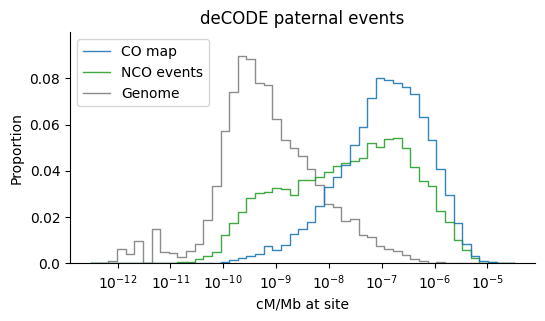

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.histplot(
    [
        pd.Series(np.log10(male_crossover_cms), name="CO"),
        pd.Series(np.log10(converted_male_single_nco_cms), name="NCO"),
        pd.Series(np.log10(male_random_cms), name="All reads"),
    ],
    bins=np.linspace(-12.5, -4.5, 50),
    stat="proportion",
    common_norm=False,
    element="step",
    palette=[CO_color, NCO_color, background_color],
    fill=False,
    alpha=0.9,
    ax=ax,
    lw=1,
)

ax.set_title("deCODE paternal events")
ax.set_xlabel("cM/Mb at site")
ax.set_ylabel("Proportion")
ax.set_xticks(
    np.arange(-12, -4),
    [f"$10^{{{x}}}$" for x in np.arange(-12, -4)],
)
ax.set_yticks(
    np.arange(0, 0.1, 0.02),
    [f"{x}" for x in np.arange(0, 0.1, 0.02)],
)
ax.set_ylim(0, 0.1)
ax.legend(
    ax.get_legend().legend_handles,
    ["CO map", "NCO events", "Genome"],
    loc="upper left",
)
ax.spines[["right", "top"]].set_visible(False)

fig.savefig(figure_dir / "decode_paternal_events.pdf")

In [14]:
import sklearn.neighbors

CO_kde = sklearn.neighbors.KernelDensity().fit(np.log10(male_crossover_cms).reshape((-1, 1)))

B = np.log10(male_random_cms)
B = B[~np.isnan(B)]
all_kde = sklearn.neighbors.KernelDensity().fit(B.reshape((-1, 1)))

C = np.log10(converted_male_single_nco_cms)
C = C[~np.isnan(C)]

def score(p):
    return np.log(
        np.exp(CO_kde.score_samples(C.reshape((-1, 1)))) * p +
        np.exp(all_kde.score_samples(C.reshape((-1, 1)))) * (1 - p)
    ).sum()

decode_map_component = scipy.optimize.minimize_scalar(lambda p: -score(p), bounds=[0, 1]).x
decode_background_component = 1 - decode_map_component

decode_background_component

np.float64(0.225966327252611)

## Fragile sites

In [15]:
fragile_df = pl.concat([
    pl.read_csv(
        filename,
        new_columns=["chrom", "start_pos", "end_pos", "fragile_site_name", "something", "something_else"],
        separator="\t",
        infer_schema=False,
    )
    for filename in glob.glob("/lustre/scratch122/tol/projects/sperm/data/references/10.HumCFS/fragile_site_bed/chr*_fragile_site.bed")
])

In [16]:
xdf = extended_male_single_nco_df

dfs = []
for chrom in tqdm.tqdm(aut_chrom_names):
    dfs.append(
        xdf
        .filter(pl.col("Chr") == chrom)
        .select("Chr", "Begin", "End", "grch37_cm_mb", "grch37_avg_cm_mb")
        .sort("Begin")
        .set_sorted("Begin")
        .join_asof(
            (
                fragile_df
                .filter(pl.col("chrom") == chrom)
                .select(
                    region_start_pos=pl.col("start_pos").cast(int),
                    region_end_pos=pl.col("end_pos").cast(int),
                )
                .sort("region_end_pos")
            ),
            left_on="Begin",
            right_on="region_end_pos",
            strategy="forward",
        )
        .with_columns(
            in_fragile_site=(
                pl.col("Begin").is_not_null() &
                pl.col("End").is_not_null() &
                pl.col("region_start_pos").is_not_null() &
                pl.col("region_end_pos").is_not_null() &
                (pl.col("Begin") >= pl.col("region_start_pos")) &
                (pl.col("End") <= pl.col("region_end_pos"))
            )
        )
    )

reads_in_fragile_df = pl.concat(dfs)

100%|██████████| 22/22 [00:00<00:00, 354.45it/s]


In [17]:
tbl = (
    reads_in_fragile_df
    .select(
        "in_fragile_site",
        is_low=(pl.col("grch37_avg_cm_mb").log(base=10)) < -8,
    )
    .group_by("in_fragile_site", "is_low")
    .len()
    .sort(by=["in_fragile_site", "is_low"])
)

T = tbl["len"].to_numpy()
decode_high_rate_fragile_overlap = T[2] / (T[0] + T[2])
decode_low_rate_fragile_overlap = T[3] / (T[1] + T[3])
decode_fragile_fisher_p = scipy.stats.fisher_exact(T.reshape((2, 2))).pvalue

display(tbl)

in_fragile_site,is_low,len
bool,bool,u32
false,false,6446
false,true,2520
true,false,1846
true,true,869


## Fig. 2E

In [18]:
expanded_markers_df = (
    markers_df
    .with_columns(
        grch37_pos=np.array([
            x[0][1] if len(x := lo.convert_coordinate(chrom, start)) else -1
            for chrom, start in zip(markers_df["Chr"], markers_df["pos"])
        ])
    )
    .filter(pl.col("grch37_pos") != -1)
)

expanded_markers_df = (
    expanded_markers_df
    .with_columns(
        grch37_male_cm_mb=np.array([annotate.male_rate_maps[x[0]].get_rate(x[1]) for x in zip(expanded_markers_df["Chr"], expanded_markers_df["grch37_pos"])]),
        grch37_female_cm_mb=np.array([annotate.female_rate_maps[x[0]].get_rate(x[1]) for x in zip(expanded_markers_df["Chr"], expanded_markers_df["grch37_pos"])]),
        grch37_avg_cm_mb=np.array([annotate.avg_rate_maps[x[0]].get_rate(x[1]) for x in zip(expanded_markers_df["Chr"], expanded_markers_df["grch37_pos"])]),
    )
)

In [19]:
def clopper_pearson_ci(k: int, n: int, alpha: float = 0.05):
    if n == 0:
        return (np.nan, np.nan)
    lo = 0.0 if k == 0 else beta.ppf(alpha / 2, k, n - k + 1)
    hi = 1.0 if k == n else beta.ppf(1 - alpha / 2, k + 1, n - k)
    return (lo, hi)

def converted_marker_df(df_in, ptype_val):
    return (
        df_in
        .filter(pl.col("ptype") == ptype_val)
        .filter(pl.col("mrktype") == "snp")
        .filter(pl.col("converted") == 1)
        .filter(pl.col("gfa") != pl.col("gma"))
        .filter(
            (pl.col("gfa").is_in(["A", "T"]) & pl.col("gma").is_in(["G", "C"])) |
            (pl.col("gma").is_in(["A", "T"]) & pl.col("gfa").is_in(["G", "C"]))
        )
        .with_columns(
            gc_allele=pl.when(pl.col("gfa").is_in(["G", "C"]))
                        .then(pl.col("gfa"))
                        .otherwise(pl.col("gma"))
        )
        .with_columns(
            gc_transmitted=pl.col("allele") == pl.col("gc_allele")
        )
    )

def gc_stats(df_in, ptype_val):
    df = converted_marker_df(df_in, ptype_val)
    n = len(df)
    k = len(df.filter(pl.col("gc_transmitted")))
    lo, hi = clopper_pearson_ci(k, n)
    return {"k": k, "n": n, "gBGC": k / n, "ci_low": lo, "ci_high": hi}

alpha = 0.05
binsize = 0.5

def bias_by_bin(df_in: pl.DataFrame, rate_col: str, ptype_val: str):
    xs, ys = [], []
    err_lo, err_hi = [], []

    for lower_range in np.arange(-10.4, -5.5, binsize):
        df = converted_marker_df(
            df_in
            .filter(pl.col(rate_col).log10() >= lower_range)
            .filter(pl.col(rate_col).log10() < lower_range + binsize),
            ptype_val,
        )

        n = len(df)
        if n == 0:
            xs.append(lower_range)
            ys.append(np.nan)
            err_lo.append(np.nan)
            err_hi.append(np.nan)
            continue

        k = len(df.filter(pl.col("gc_transmitted")))
        p = k / n
        lo, hi = clopper_pearson_ci(k, n, alpha=alpha)

        xs.append(lower_range)
        ys.append(p)
        err_lo.append(p - lo)
        err_hi.append(hi - p)

    return np.array(xs), np.array(ys), np.vstack([err_lo, err_hi])

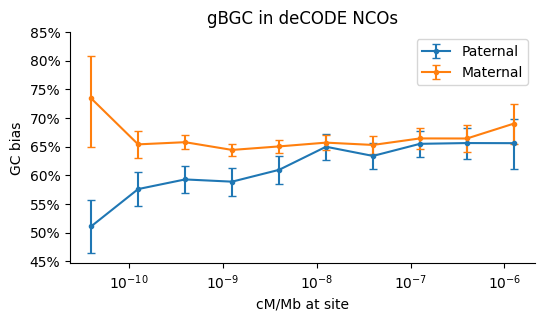

In [20]:
male_xs, male_ys, male_yerr = bias_by_bin(expanded_markers_df, "grch37_male_cm_mb", "P")
female_xs, female_ys, female_yerr = bias_by_bin(expanded_markers_df, "grch37_female_cm_mb", "M")

fig, ax = plt.subplots(figsize=(6, 3))

ax.errorbar(male_xs, male_ys, yerr=male_yerr, fmt=".-", capsize=3)
ax.errorbar(female_xs, female_ys, yerr=female_yerr, fmt=".-", capsize=3)
ax.set_title("gBGC in deCODE NCOs")
ax.set_xlabel("cM/Mb at site")
ax.set_ylabel("GC bias")
ax.legend(["Paternal", "Maternal"])

ax.set_xticks(
    np.arange(-10, -5),
    [f"$10^{{{x}}}$" for x in np.arange(-10, -5)],
)
ax.set_yticks(
    np.arange(0.45, 0.9, 0.05),
    [f"{int(x)}%" for x in np.arange(45, 90, 5)],
)
ax.spines[["right", "top"]].set_visible(False)

fig.savefig(figure_dir / "decode_gc_bias.pdf")

In [21]:
decode_paternal_gbgc = gc_stats(markers_df, "P")
decode_maternal_gbgc = gc_stats(markers_df, "M")

decode_paternal_high_rate_gbgc = gc_stats(
    expanded_markers_df.filter(pl.col("grch37_male_cm_mb").log10() > -7),
    "P",
)

decode_maternal_low_rate_gbgc = gc_stats(
    expanded_markers_df.filter(pl.col("grch37_female_cm_mb").log10() < -8),
    "M",
)

decode_paternal_gbgc, decode_maternal_gbgc

({'k': 8435,
  'n': 13622,
  'gBGC': 0.619218910585817,
  'ci_low': np.float64(0.6110031208116186),
  'ci_high': np.float64(0.6273837422207567)},
 {'k': 23654,
  'n': 36142,
  'gBGC': 0.6544740191466991,
  'ci_low': np.float64(0.649545300850293),
  'ci_high': np.float64(0.659377904883228)})

## Summary

In [22]:
key_values = {
    "deCODE paternal gBGC": decode_paternal_gbgc["gBGC"],
    "deCODE paternal gBGC CI low": decode_paternal_gbgc["ci_low"],
    "deCODE paternal gBGC CI high": decode_paternal_gbgc["ci_high"],
    "deCODE paternal gBGC n": decode_paternal_gbgc["n"],
    "deCODE maternal gBGC": decode_maternal_gbgc["gBGC"],
    "deCODE maternal gBGC CI low": decode_maternal_gbgc["ci_low"],
    "deCODE maternal gBGC CI high": decode_maternal_gbgc["ci_high"],
    "deCODE maternal gBGC n": decode_maternal_gbgc["n"],
    "deCODE paternal high-rate gBGC": decode_paternal_high_rate_gbgc["gBGC"],
    "deCODE maternal low-rate gBGC": decode_maternal_low_rate_gbgc["gBGC"],
    "deCODE map-like component": decode_map_component,
    "deCODE background-like component": decode_background_component,
    "deCODE low-rate paternal NCO fragile overlap": decode_low_rate_fragile_overlap,
    "deCODE high-rate paternal NCO fragile overlap": decode_high_rate_fragile_overlap,
    "deCODE fragile Fisher P": decode_fragile_fisher_p,
}

key_values

{'deCODE paternal gBGC': 0.619218910585817,
 'deCODE paternal gBGC CI low': np.float64(0.6110031208116186),
 'deCODE paternal gBGC CI high': np.float64(0.6273837422207567),
 'deCODE paternal gBGC n': 13622,
 'deCODE maternal gBGC': 0.6544740191466991,
 'deCODE maternal gBGC CI low': np.float64(0.649545300850293),
 'deCODE maternal gBGC CI high': np.float64(0.659377904883228),
 'deCODE maternal gBGC n': 36142,
 'deCODE paternal high-rate gBGC': 0.6548919949174079,
 'deCODE maternal low-rate gBGC': 0.6502608940911014,
 'deCODE map-like component': np.float64(0.774033672747389),
 'deCODE background-like component': np.float64(0.225966327252611),
 'deCODE low-rate paternal NCO fragile overlap': np.float64(0.2564178223664798),
 'deCODE high-rate paternal NCO fragile overlap': np.float64(0.2226242161119151),
 'deCODE fragile Fisher P': np.float64(0.00010146833549084063)}